# Content Concreteness vs Abstraction

Source paper: https://link.springer.com/article/10.3758/s13428-013-0403-5?utm_source=chatgpt.com

In [1]:
import pandas as pd
import numpy as np

# Example using Brysbaert et al. 2014 (download CSV first)
concreteness = pd.read_excel("concreteness_ratings_Brysbaert_et_al_2014.xlsx")

def concreteness_score(word):
    score = concreteness.loc[
        concreteness['Word'].str.lower() == word.lower(), 'Conc.M'
    ].values

    if len(score):
        print(f"Concreteness score for '{word}': {score[0]:.2f} (1=abstract, 5=concrete)")
    else:
        print(f"'{word}' not found in the dataset.")

In [2]:
words = ["justice", "idea", "democracy", "truth", "joy", "holiday", "food", "car", "tree", "apple"]
for word in words:
    concreteness_score(word)

Concreteness score for 'justice': 1.45 (1=abstract, 5=concrete)
Concreteness score for 'idea': 1.61 (1=abstract, 5=concrete)
Concreteness score for 'democracy': 1.78 (1=abstract, 5=concrete)
Concreteness score for 'truth': 1.96 (1=abstract, 5=concrete)
Concreteness score for 'joy': 2.37 (1=abstract, 5=concrete)
Concreteness score for 'holiday': 2.86 (1=abstract, 5=concrete)
Concreteness score for 'food': 4.80 (1=abstract, 5=concrete)
Concreteness score for 'car': 4.89 (1=abstract, 5=concrete)
Concreteness score for 'tree': 5.00 (1=abstract, 5=concrete)
Concreteness score for 'apple': 5.00 (1=abstract, 5=concrete)


In [3]:
# load cleaned data
df_articles = pd.read_pickle("../../data/processed/cleaned_articles.pkl")

print(f"Total number of articles: {df_articles.shape[0]:,}")

Total number of articles: 39,863


# Optimized version with progress tracking

In [5]:
import numpy as np
import spacy
from tqdm.auto import tqdm

# -----------------------------------------
# 1. Precompute dictionary for O(1) lookup
# -----------------------------------------

concreteness_dict = (
    concreteness
    .assign(Word=concreteness['Word'].str.lower())
    .set_index('Word')['Conc.M']
    .to_dict()
)

def concreteness_rating(word):
    return concreteness_dict.get(word, np.nan)


# -----------------------------------------
# 2. Load spaCy efficiently
# -----------------------------------------

nlp = spacy.load(
    "en_core_web_sm",
    disable=["ner", "parser"]
)

nlp.enable_pipe("lemmatizer")
nlp.max_length = 5_000_000


# -----------------------------------------
# 3. Function with tqdm progress bar
# -----------------------------------------

def compute_concreteness_scores(texts, batch_size=500):
    """
    Compute concreteness scores for many documents using spaCy.pipe() + tqdm.
    """

    results = []

    # tqdm gives progress bar over batches
    for doc in tqdm(
        nlp.pipe(texts, batch_size=batch_size),
        total=len(texts),
        desc="Processing documents"
    ):
        vals = [
            concreteness_rating(token.lemma_.lower())
            for token in doc
            if token.is_alpha and not token.is_stop
            and not np.isnan(concreteness_rating(token.lemma_.lower()))
        ]

        results.append(float(np.mean(vals)) if vals else np.nan)

    return results


# -----------------------------------------
# 4. Run on your DataFrame
# -----------------------------------------

df_articles['concreteness_score'] = compute_concreteness_scores(
    df_articles['body'].tolist()
)


Processing documents:   0%|          | 0/39863 [00:00<?, ?it/s]

In [14]:
def line_time_plot_numeric(
    df_articles_with_results,
    nyt_mask,
    variable,
    title,
    filename,
    variable_label=None,
    smooth_window=3  # rolling average window; set to None to disable smoothing
):
    """
    Plot a single line chart showing the mean value of a numerical variable per year,
    comparing NYT vs Other Publishers.

    Parameters
    ----------
    df_articles_with_results : pandas.DataFrame
        DataFrame containing 'year' and the numeric variable.
    nyt_mask : pandas.Series[bool]
        Boolean mask selecting NYT articles.
    variable : str
        Column name of the numeric variable.
    title : str
        Title of the plot.
    variable_label : str, optional
        Y-axis label. Defaults to the column name.
    smooth_window : int or None, optional
        Rolling window size for smoothing lines. If None, no smoothing is applied.
    """
    if variable_label is None:
        variable_label = variable

    # Two groups: NYT and non-NYT
    groups = {
        "NYT": nyt_mask,
        "Other Publishers": ~nyt_mask
    }

    plt.figure(figsize=(12, 6))

    for label, mask in groups.items():
        grouped = (
            df_articles_with_results[mask]
            .groupby("year")[variable]
            .mean()
            .sort_index()
        )

        # Optional smoothing
        if smooth_window is not None and smooth_window > 1:
            grouped = grouped.rolling(window=smooth_window, min_periods=1).mean()

        plt.plot(
            grouped.index,
            grouped.values,
            linewidth=2,
            label=label,
        )

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(variable_label)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=300, facecolor="white", edgecolor="none")
    plt.show()


In [16]:
df_articles['year'] = pd.to_datetime(df_articles["date"]).dt.year
nyt_mask = df_articles["publisher"] == "New York Times"

In [17]:
import matplotlib.pyplot as plt

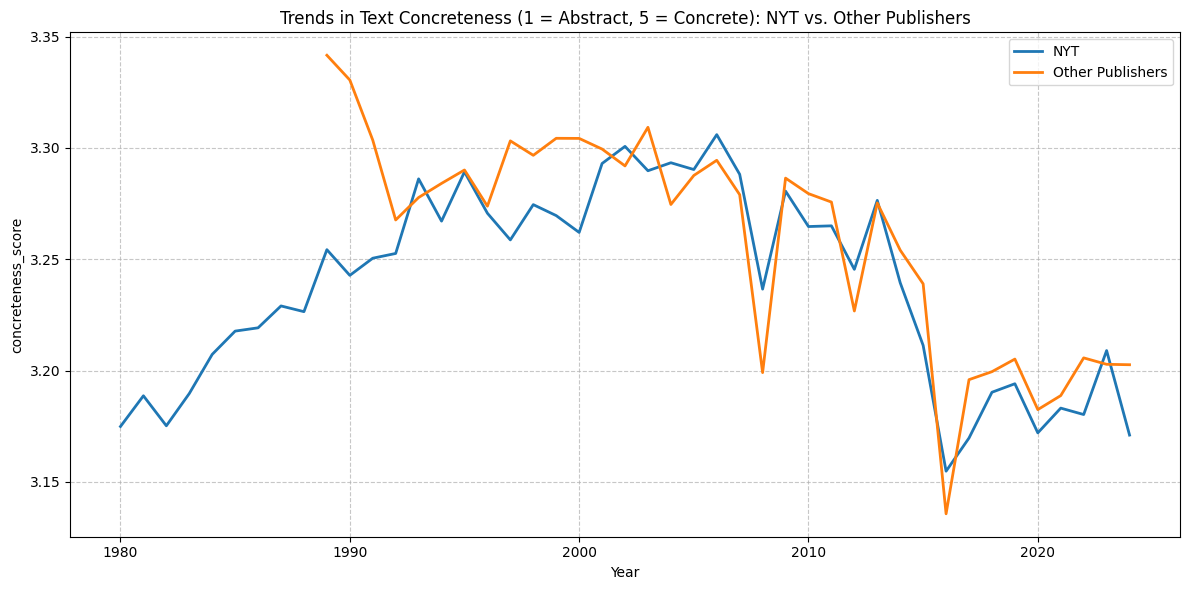

In [18]:
line_time_plot_numeric(
    df_articles,
    nyt_mask,
    'concreteness_score',
    "Trends in Text Concreteness (1 = Abstract, 5 = Concrete): NYT vs. Other Publishers",
    'concreteness_score_time_comparison.png',
    variable_label=None,
    smooth_window=None
)